# Notebook 5: Probability

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What is Probability?

Probability is a number between 0 and 1 that tells us **how likely an event is to happen**. 0 means impossible, 1 means certain.

**Analogy:** A weather app says "70% chance of rain". That means that on days with similar conditions, it rained about 7 out of 10 times.

**Why it matters in AI/ML:** Models deal with uncertainty. A spam filter says "95% spam", a classifier outputs class probabilities, and algorithms like Naive Bayes are built directly on probability.

**Topics covered:** Introduction, Events, Sample Space, Independent and Dependent Events, Conditional Probability, Bayes' Theorem, Probability Rules, Random Variables, Expected Value.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

np.random.seed(42)

## 1. Introduction to Probability

**Definition:** Probability of an event is the number of favourable outcomes divided by the total number of equally likely outcomes.

**Formula:**

$$P(A) = \frac{\text{Number of favourable outcomes}}{\text{Total number of outcomes}}, \quad 0 \le P(A) \le 1$$

**Numerical Example:** Rolling a fair die. P(getting 4) = 1 / 6 = **0.1667**.

**Business Example:** An insurance company estimates the probability that a customer makes a claim in a year to set the premium.

**AI/ML Example:** A classifier like Logistic Regression outputs P(class = 1). We compare it with a threshold (0.5) to make the final decision.

In [2]:
# Theoretical
print("Theory P(4):", round(1 / 6, 4))

# Simulation: roll a die 100000 times
rolls = np.random.randint(1, 7, size=100000)
print("Simulated P(4):", round(np.mean(rolls == 4), 4))

# Law of large numbers: probability gets closer to theory as trials grow
for n in [10, 100, 1000, 10000, 100000]:
    print(f"n = {n:>6} -> P(4) = {np.mean(rolls[:n] == 4):.4f}")

Theory P(4): 0.1667
Simulated P(4): 0.1678
n =     10 -> P(4) = 0.1000
n =    100 -> P(4) = 0.2500
n =   1000 -> P(4) = 0.1740
n =  10000 -> P(4) = 0.1672
n = 100000 -> P(4) = 0.1678


**Explanation:** We roll a die 100,000 times and count how often a 4 appears. Then we check the result using only the first n rolls.

**Interpretation:** With few rolls the result is far from 0.1667, and with many rolls it gets very close. This is the **Law of Large Numbers**: more trials give a more accurate probability estimate. In ML, more data gives more reliable estimates.

## 2. Sample Space and Events

**Definition:**
- **Sample space (S):** the set of all possible outcomes of an experiment.
- **Event (A):** a subset of the sample space, one or more outcomes we care about.

**Types of events:**
- **Simple event:** a single outcome (getting 4)
- **Compound event:** more than one outcome (getting an even number)
- **Mutually exclusive:** cannot happen together (getting 2 and getting 5 in one roll)
- **Complement (A'):** event A does not happen

**Numerical Example:** Rolling one die.
S = {1, 2, 3, 4, 5, 6}
Event A (even number) = {2, 4, 6}, so P(A) = 3 / 6 = **0.5**
Complement A' (odd) = {1, 3, 5}, so P(A') = 1 - 0.5 = **0.5**

**Business Example:** For an online store, the sample space of a visitor's action is {buy, add to cart, leave}. The event "does not buy" is a compound event.

**AI/ML Example:** In classification, the sample space is the set of all classes (for example, {cat, dog, bird}), and the model assigns a probability to each outcome.

In [3]:
# Sample space of one die
S = {1, 2, 3, 4, 5, 6}
A = {x for x in S if x % 2 == 0}      # even numbers
A_complement = S - A

print("Sample space:", S)
print("Event A (even):", A, "| P(A) =", len(A) / len(S))
print("Complement   :", A_complement, "| P(A') =", len(A_complement) / len(S))

# Sample space of two coins
coins = list(product(["H", "T"], repeat=2))
print("\nTwo coins sample space:", coins)
at_least_one_head = [c for c in coins if "H" in c]
print("P(at least one head) =", len(at_least_one_head) / len(coins))

Sample space: {1, 2, 3, 4, 5, 6}
Event A (even): {2, 4, 6} | P(A) = 0.5
Complement   : {1, 3, 5} | P(A') = 0.5

Two coins sample space: [('H', 'H'), ('H', 'T'), ('T', 'H'), ('T', 'T')]
P(at least one head) = 0.75


**Explanation:** We represent the sample space as a Python set, define an event with a condition, and take the complement using set difference. For two coins, `product` lists every combination.

**Interpretation:** The sample space of two coins has 4 outcomes, and 3 of them contain at least one head, so the probability is 0.75. Listing the sample space is the safest way to solve small probability problems.

## 3. Probability Rules

**Definition and Formulas:**

1. **Complement rule:** the probability that A does not happen.

$$P(A') = 1 - P(A)$$

2. **Addition rule (OR):**

$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

If A and B are mutually exclusive, then P(A ∩ B) = 0.

3. **Multiplication rule (AND):**

$$P(A \cap B) = P(A) \times P(B \mid A)$$

If A and B are independent, then P(A ∩ B) = P(A) × P(B).

**Numerical Example:** Drawing one card from a deck of 52.
- P(King) = 4/52, P(Heart) = 13/52, P(King of Hearts) = 1/52
- P(King OR Heart) = 4/52 + 13/52 - 1/52 = 16/52 = **0.3077**

**Business Example:** A marketing team wants the chance that a customer opens an email OR clicks an ad, without counting people who did both twice.

**AI/ML Example:** The multiplication rule is the base of the **chain rule** used in Naive Bayes and language models: P(word1, word2, word3) = P(word1) × P(word2 | word1) × P(word3 | word1, word2).

In [4]:
# Card example
p_king = 4 / 52
p_heart = 13 / 52
p_king_and_heart = 1 / 52

p_king_or_heart = p_king + p_heart - p_king_and_heart
print("P(King OR Heart):", round(p_king_or_heart, 4))
print("P(not King):", round(1 - p_king, 4))

# Verify by simulation
suits = ["Heart", "Diamond", "Club", "Spade"]
ranks = ["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"]
deck = [(r, s) for r in ranks for s in suits]

draws = [deck[i] for i in np.random.randint(0, 52, 100000)]
sim = np.mean([(r == "K" or s == "Heart") for r, s in draws])
print("Simulated P(King OR Heart):", round(sim, 4))

P(King OR Heart): 0.3077
P(not King): 0.9231
Simulated P(King OR Heart): 0.3078


**Explanation:** We use the addition rule, subtracting the overlap (King of Hearts) so it is not counted twice. Then we verify using a simulated deck.

**Interpretation:** The formula result (0.3077) and the simulation are very close. If we forgot to subtract the overlap, we would get 0.327, which is wrong.

## 4. Independent Events

**Definition:** Two events are independent if the occurrence of one does **not change** the probability of the other.
m
**Formula:**

$$P(A \cap B) = P(A) \times P(B) \qquad P(A \mid B) = P(A)$$

**Numerical Example:** Tossing a coin twice. P(Head on 1st) = 0.5, P(Head on 2nd) = 0.5.
P(both heads) = 0.5 × 0.5 = **0.25**. The first toss does not affect the second.

**Business Example:** Two customers independently visiting a store. One customer buying does not change the other's decision.

**AI/ML Example:** **Naive Bayes** assumes that all features are independent of each other given the class. This "naive" assumption makes the calculation simple and fast. Train-test samples are also assumed to be independent (i.i.d.).

In [6]:
# Two coin tosses
n = 100000
toss1 = np.random.randint(0, 2, n)   # 1 = head
toss2 = np.random.randint(0, 2, n)

p_both = np.mean((toss1 == 1) & (toss2 == 1))
print("Theory P(both heads):", 0.5 * 0.5)
print("Simulated           :", round(p_both, 4))

# Check independence: P(2nd head | 1st head) should equal P(2nd head)
p_second = np.mean(toss2 == 1)
p_second_given_first = np.mean(toss2[toss1 == 1] == 1)
print("\nP(2nd head)              :", round(p_second, 4))
print("P(2nd head | 1st head)   :", round(p_second_given_first, 4))

Theory P(both heads): 0.25
Simulated           : 0.2493

P(2nd head)              : 0.4987
P(2nd head | 1st head)   : 0.4964


**Explanation:** We simulate two coin tosses 100,000 times and check the multiplication rule. Then we compare P(2nd head) and P(2nd head | 1st head).

**Interpretation:** Both values are about 0.5, so knowing the first result does not change the second. That is the definition of independence.

## 5. Dependent Events

**Definition:** Two events are dependent if the occurrence of one **changes** the probability of the other. A common case is drawing **without replacement**.

**Formula:**

$$P(A \cap B) = P(A) \times P(B \mid A)$$

**Numerical Example:** A bag has 3 red and 2 blue balls. Draw two balls without replacement.
P(1st red) = 3/5
P(2nd red | 1st red) = 2/4 (one red is already gone)
P(both red) = 3/5 × 2/4 = 6/20 = **0.3**

**Business Example:** A company has 5 open positions and picks candidates from a pool. Each selection changes the pool and the chances for the others.

**AI/ML Example:** In time series and language data, the next value depends on previous values (a word depends on the words before it). Markov models and RNNs are built for dependent events.

In [7]:
red, blue = 3, 2
total = red + blue

p_both_red = (red / total) * ((red - 1) / (total - 1))
print("Theory P(both red):", p_both_red)

# Simulation without replacement
bag = ["R"] * red + ["B"] * blue
count = 0
trials = 100000
for _ in range(trials):
    draw = np.random.choice(bag, size=2, replace=False)
    if draw[0] == "R" and draw[1] == "R":
        count += 1
print("Simulated         :", round(count / trials, 4))

# If it was with replacement (independent)
print("With replacement  :", (red / total) ** 2)

Theory P(both red): 0.3
Simulated         : 0.2994
With replacement  : 0.36


**Explanation:** Without replacement, the second probability uses the reduced bag (2 red out of 4). We verify with simulation using `replace=False` and compare with the independent case.

**Interpretation:** Dependent probability is 0.3, while with replacement (independent) it would be 0.36. The difference shows that the first draw changes the second.

## 6. Conditional Probability

**Definition:** The probability of event A happening **given that** event B has already happened.

**Formula:**

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

**Numerical Example:** In a class of 100 students, 60 study Python, 40 study SQL, and 25 study both.
P(SQL | Python) = P(both) / P(Python) = 0.25 / 0.60 = **0.4167**
Among Python students, about 41.7% also study SQL.

**Business Example:** "Given that a customer bought a laptop, what is the probability they also buy a laptop bag?" Stores use this for cross-selling.

**AI/ML Example:** Every classifier estimates **P(class | features)**. Recommendation systems estimate P(user likes item B | user liked item A).

In [8]:
# Student data
total = 100
python = 60
sql = 40
both = 25

p_python = python / total
p_both = both / total
p_sql_given_python = p_both / p_python

print("P(Python)       :", p_python)
print("P(Python & SQL) :", p_both)
print("P(SQL | Python) :", round(p_sql_given_python, 4))

# Using a DataFrame
df = pd.DataFrame({
    "python": [1] * 25 + [1] * 35 + [0] * 15 + [0] * 25,
    "sql":    [1] * 25 + [0] * 35 + [1] * 15 + [0] * 25,
})
print("\nFrom data:", round(df[df["python"] == 1]["sql"].mean(), 4))

P(Python)       : 0.6
P(Python & SQL) : 0.25
P(SQL | Python) : 0.4167

From data: 0.4167


**Explanation:** We divide the probability of both events by the probability of the given event. Then we check it in a DataFrame by filtering to Python students and taking the SQL average.

**Interpretation:** Among Python students, 41.7% also study SQL, which is higher than the overall SQL rate (40%). The condition changed the probability, so SQL and Python are slightly dependent.

## 7. Bayes' Theorem

**Definition:** Bayes' Theorem updates the probability of a hypothesis after seeing new evidence. It reverses a conditional probability: from P(evidence | cause) to P(cause | evidence).

**Formula:**

$$P(A \mid B) = \frac{P(B \mid A) \times P(A)}{P(B)}$$

where

$$P(B) = P(B \mid A)P(A) + P(B \mid A')P(A')$$

- P(A) = **prior** (belief before evidence)
- P(B | A) = **likelihood**
- P(A | B) = **posterior** (belief after evidence)

**Numerical Example (medical test):**
- 1% of people have a disease: P(D) = 0.01
- Test is positive for 99% of sick people: P(+ | D) = 0.99
- Test is wrongly positive for 5% of healthy people: P(+ | not D) = 0.05

P(+) = 0.99 × 0.01 + 0.05 × 0.99 = 0.0099 + 0.0495 = 0.0594
P(D | +) = 0.0099 / 0.0594 = **0.1667 (about 16.7%)**

Even after a positive result, there is only a 16.7% chance of having the disease, because the disease is rare.

**Business Example:** A bank estimates the probability that a transaction is fraud given that it is flagged by the system.

**AI/ML Example:** **Naive Bayes classifier** uses Bayes' Theorem for spam detection: P(spam | words) = P(words | spam) × P(spam) / P(words).

In [9]:
p_disease = 0.01
p_pos_given_disease = 0.99
p_pos_given_healthy = 0.05

p_healthy = 1 - p_disease
p_pos = p_pos_given_disease * p_disease + p_pos_given_healthy * p_healthy

p_disease_given_pos = (p_pos_given_disease * p_disease) / p_pos

print("P(positive)           :", round(p_pos, 4))
print("P(disease | positive) :", round(p_disease_given_pos, 4))

# Simulation: 1,000,000 people
n = 1_000_000
sick = np.random.rand(n) < p_disease
test_pos = np.where(sick, np.random.rand(n) < p_pos_given_disease, np.random.rand(n) < p_pos_given_healthy)
print("Simulated P(disease | positive):", round(sick[test_pos].mean(), 4))

# Spam example
p_spam = 0.3
p_word_given_spam = 0.6      # P("offer" | spam)
p_word_given_ham = 0.05      # P("offer" | not spam)
p_word = p_word_given_spam * p_spam + p_word_given_ham * (1 - p_spam)
print("\nP(spam | 'offer'):", round(p_word_given_spam * p_spam / p_word, 4))

P(positive)           : 0.0594
P(disease | positive) : 0.1667
Simulated P(disease | positive): 0.169

P(spam | 'offer'): 0.8372


**Explanation:** We compute the total probability of a positive test, then apply Bayes' formula. The simulation of 1 million people confirms it. The spam example applies the same formula to a word.

**Interpretation:** Only about 16.7% of positive-tested people are actually sick, because the healthy group is so large that its false positives outnumber the true positives. This is called the **base rate effect**. For spam, seeing the word "offer" raises the spam probability from 30% to about 84%.

## 8. Random Variables

**Definition:** A random variable is a variable whose value is the **numerical outcome of a random experiment**.
- **Discrete random variable:** takes countable values (number of heads in 3 tosses).
- **Continuous random variable:** takes any value in a range (height, waiting time).

**Formula:** Probability Mass Function (discrete) must satisfy:

$$\sum P(X = x) = 1, \quad P(X = x) \ge 0$$

**Numerical Example:** X = number of heads in 2 coin tosses.

| X | 0 | 1 | 2 |
|---|---|---|---|
| P(X) | 0.25 | 0.50 | 0.25 |

The probabilities add to 1.

**Business Example:** X = number of customers arriving at a shop in an hour, or X = daily sales amount.

**AI/ML Example:** Every feature and target in a dataset is treated as a random variable. A model learns the relationship between random variables.

0    0.25
1    0.50
2    0.25
Name: proportion, dtype: float64
Sum of probabilities: 1.0


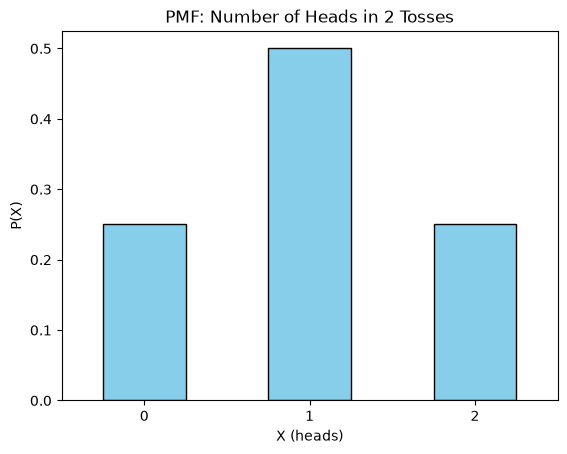

In [10]:
# X = number of heads in 2 tosses
outcomes = list(product([0, 1], repeat=2))        # 1 = head
X = [sum(o) for o in outcomes]

pmf = pd.Series(X).value_counts(normalize=True).sort_index()
print(pmf)
print("Sum of probabilities:", pmf.sum())

pmf.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("PMF: Number of Heads in 2 Tosses")
plt.xlabel("X (heads)")
plt.ylabel("P(X)")
plt.xticks(rotation=0)
plt.show()

**Explanation:** We list all 4 outcomes, count heads in each, and convert the counts into probabilities (the PMF). The bar chart shows the distribution of the random variable.

**Interpretation:** One head is the most likely (0.5), and 0 or 2 heads are each 0.25. The probabilities sum to 1, as required.

## 9. Expected Value

**Definition:** The expected value is the **long-run average** of a random variable if the experiment is repeated many times. It is the weighted mean of all outcomes, where the weights are probabilities.

**Formula:**

$$E[X] = \sum x_i \cdot P(x_i)$$

$$Var(X) = E[X^2] - (E[X])^2$$

**Numerical Example:** A game: roll a die. You win Rs. 10 if you roll 6, win Rs. 2 if you roll 4 or 5, and lose Rs. 3 otherwise.

| Outcome | Probability | Value |
|---|---|---|
| 6 | 1/6 | +10 |
| 4 or 5 | 2/6 | +2 |
| 1, 2, 3 | 3/6 | -3 |

E[X] = (1/6)(10) + (2/6)(2) + (3/6)(-3) = 1.667 + 0.667 - 1.5 = **Rs. 0.833** per game.

**Business Example:** A company estimates expected profit of a project: 40% chance of Rs. 10 lakh profit, 60% chance of Rs. 2 lakh loss. E = 0.4 × 10 - 0.6 × 2 = Rs. 2.8 lakh.

**AI/ML Example:** The **loss function** of a model is an expected value of errors over the data. In Reinforcement Learning, the agent maximizes the **expected reward**.

In [11]:
values = np.array([10, 2, -3])
probs = np.array([1/6, 2/6, 3/6])

expected = np.sum(values * probs)
variance = np.sum((values ** 2) * probs) - expected ** 2

print("Expected value:", round(expected, 4))
print("Variance      :", round(variance, 4))
print("Std deviation :", round(np.sqrt(variance), 4))

# Simulation: play the game many times
rolls = np.random.randint(1, 7, 200000)
winnings = np.where(rolls == 6, 10, np.where((rolls == 4) | (rolls == 5), 2, -3))
print("\nAverage over 200000 games:", round(winnings.mean(), 4))

# Business project example
print("Expected project profit (lakh):", 0.4 * 10 + 0.6 * (-2))

Expected value: 0.8333
Variance      : 21.8056
Std deviation : 4.6696

Average over 200000 games: 0.841
Expected project profit (lakh): 2.8


**Explanation:** We multiply each outcome by its probability and add them. Then we simulate 200,000 games and take the average.

**Interpretation:** The expected value is about Rs. 0.83 per game, and the simulated average comes very close. A positive expected value means the game favours the player in the long run, even though individual games can lose. Businesses and RL agents use expected value to choose the best decision.

## Summary

| Concept | Formula | Key point |
|---|---|---|
| Probability | favourable / total | Value between 0 and 1 |
| Complement | 1 - P(A) | Event does not happen |
| Addition rule | P(A) + P(B) - P(A∩B) | OR, avoid double counting |
| Independent | P(A) × P(B) | One does not affect the other |
| Dependent | P(A) × P(B\|A) | One changes the other |
| Conditional | P(A∩B) / P(B) | Probability given a condition |
| Bayes' Theorem | P(B\|A)P(A) / P(B) | Updates belief with evidence |
| Expected value | Σ x·P(x) | Long-run average |

## Advantages
- Helps handle uncertainty in a mathematical way
- Forms the base of Naive Bayes, Logistic Regression, probabilistic models and RL
- Bayes' Theorem allows updating predictions as new data arrives
- Expected value supports business and risk decisions

## Limitations
- Needs correct assumptions (independence, equally likely outcomes) that may not hold in real data
- Probabilities estimated from small data can be unreliable
- Bayes' result depends strongly on the prior, and a wrong prior gives a wrong answer
- Humans often misinterpret conditional probabilities (the base rate fallacy)